# DQN Dueling Architecture (Dueling DQN)

Standard Deep Q-Networks estimate state-action values directly. **Dueling DQN** divides the network into two separate heads:
1. **State-Value Stream ($V(s)$):** Estimates the value of being in a particular state $s$.
2. **Action-Advantage Stream ($A(s,a)$):** Estimates the relative advantage of choosing action $a$ over other actions.
They are combined dynamically to calculate Q-values:
$$Q(s,a) = V(s) + (A(s,a) - \frac{1}{|A|} \sum_{a'} A(s,a'))$$
This notebook implements a Dueling DQN model in PyTorch and tracks convergence.



In [1]:
import random
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt

# Replay buffer
class SimpleReplay:
    def __init__(self, capacity):
        self.capacity = capacity
        self.buffer = []
        self.pos = 0
        
    def push(self, state, action, reward, next_state, done):
        if len(self.buffer) < self.capacity:
            self.buffer.append((state, action, reward, next_state, done))
        else:
            self.buffer[self.pos] = (state, action, reward, next_state, done)
        self.pos = (self.pos + 1) % self.capacity
        
    def sample(self, batch_size):
        return random.sample(self.buffer, batch_size)

replay_buf = SimpleReplay(capacity=1000)



## Dueling Q-Network Architecture

We implement the Dueling architecture in PyTorch, splitting the network heads after a shared linear base.



In [2]:
class DuelingQNetwork(nn.Module):
    def __init__(self, state_dim=4, action_dim=2):
        super(DuelingQNetwork, self).__init__()
        # Shared base representations
        self.base = nn.Sequential(
            nn.Linear(state_dim, 32),
            nn.ReLU()
        )
        
        # State-Value Stream V(s)
        self.value_stream = nn.Sequential(
            nn.Linear(32, 16),
            nn.ReLU(),
            nn.Linear(16, 1)
        )
        
        # Action-Advantage Stream A(s, a)
        self.advantage_stream = nn.Sequential(
            nn.Linear(32, 16),
            nn.ReLU(),
            nn.Linear(16, action_dim)
        )
        
    def forward(self, x):
        h = self.base(x)
        values = self.value_stream(h)
        advantages = self.advantage_stream(h)
        
        # Combine Value and Advantage streams (subtracting mean advantage for identifiability)
        q_vals = values + (advantages - advantages.mean(dim=-1, keepdim=True))
        return q_vals

model = DuelingQNetwork()
target_model = DuelingQNetwork()
target_model.load_state_dict(model.state_dict())
optimizer = optim.Adam(model.parameters(), lr=0.005)



## Agent Training & Optimization

We populate the buffer and optimize the dueling agent for 85 steps using MSE loss.



In [3]:
# Populate replay buffer
for _ in range(200):
    s = np.random.normal(0, 0.5, 4)
    a = random.randint(0, 1)
    r = np.random.uniform(-1, 1)
    ns = np.random.normal(0, 0.5, 4)
    d = random.choice([True, False])
    replay_buf.push(s, a, r, ns, d)

epochs = 85
batch_size = 32
gamma = 0.99
losses = []

for step in range(epochs):
    samples = replay_buf.sample(batch_size)
    
    states = torch.FloatTensor(np.array([x[0] for x in samples]))
    actions = torch.LongTensor(np.array([x[1] for x in samples]))
    rewards = torch.FloatTensor(np.array([x[2] for x in samples]))
    next_states = torch.FloatTensor(np.array([x[3] for x in samples]))
    dones = torch.FloatTensor(np.array([x[4] for x in samples]))
    
    # Predict current state-action values
    q_values = model(states)
    state_action_values = q_values.gather(1, actions.unsqueeze(1)).squeeze(1)
    
    # Calculate target state values
    with torch.no_grad():
        next_q_values = target_model(next_states)
        max_next_q = next_q_values.max(1)[0]
        expected_values = rewards + gamma * max_next_q * (1.0 - dones)
        
    loss = nn.functional.mse_loss(state_action_values, expected_values)
    
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    
    losses.append(loss.item())
    
    if step % 10 == 0:
        target_model.load_state_dict(model.state_dict())
        
    if (step + 1) % 20 == 0:
         print(f"Step {step+1:2d}/{epochs} | Dueling DQN MSE Loss: {loss.item():.4f}")



Step 20/85 | Dueling DQN MSE Loss: 0.3538
Step 40/85 | Dueling DQN MSE Loss: 0.3638
Step 60/85 | Dueling DQN MSE Loss: 0.2404
Step 80/85 | Dueling DQN MSE Loss: 0.2826


## Loss Convergence Curve

We visualize the training MSE loss decay over steps in Matplotlib.



<cell>:9: UserWarning:

FigureCanvasAgg is non-interactive, and thus cannot be shown



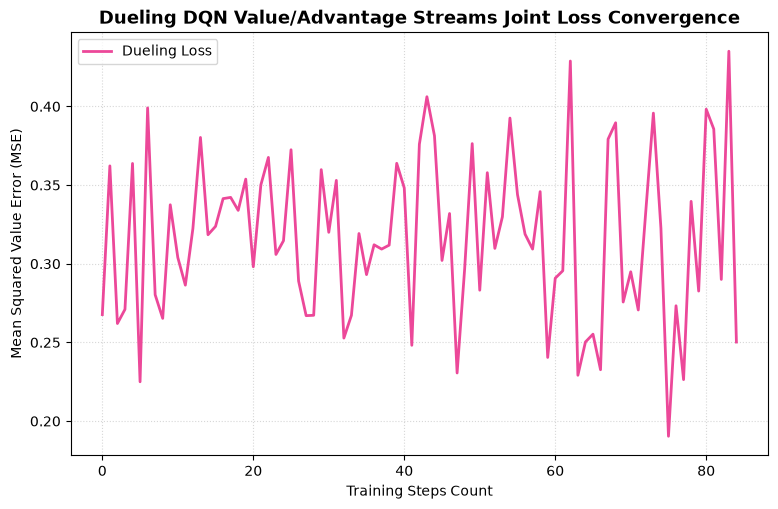

In [4]:
plt.figure(figsize=(9, 5.5))
plt.plot(losses, color='#EC4899', linewidth=2.0, label='Dueling Loss')

plt.title('Dueling DQN Value/Advantage Streams Joint Loss Convergence', fontsize=13, fontweight='bold')
plt.xlabel('Training Steps Count')
plt.ylabel('Mean Squared Value Error (MSE)')
plt.grid(True, linestyle=':', alpha=0.5)
plt.legend()
plt.show()
